In [389]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings('ignore')


In [390]:
df = pd.read_csv('insurance-2.csv')

In [391]:
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [392]:
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


**EDA**

In [393]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [394]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [395]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')

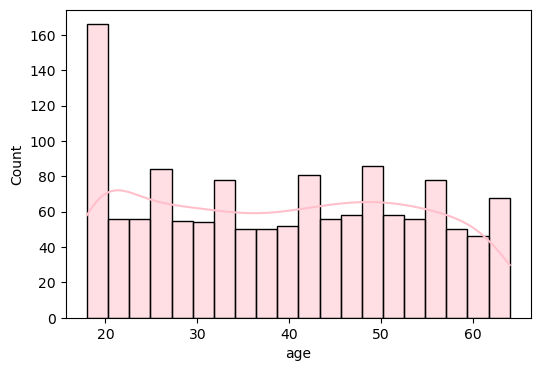

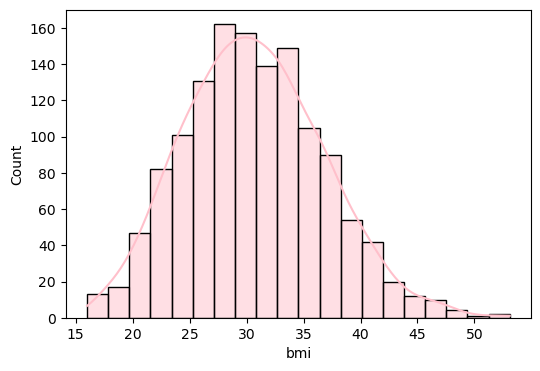

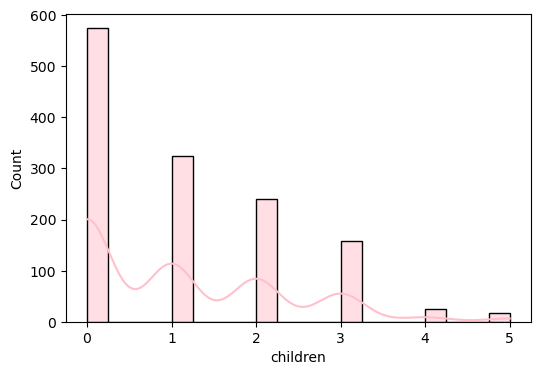

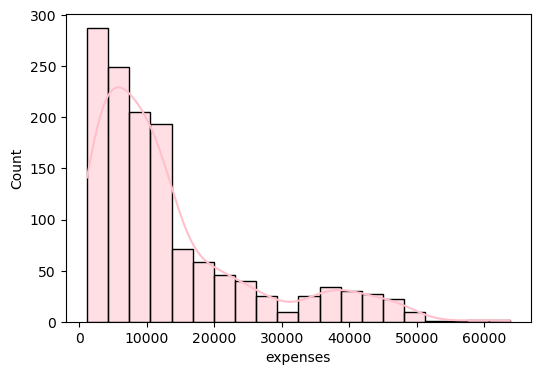

In [396]:
numeric_columns = ['age','bmi','children','expenses']
for col in numeric_columns:
    plt.figure(figsize=(6,4))

    sns.histplot(df[col],kde= True,bins = 20 ,color = "pink")

<Axes: xlabel='smoker', ylabel='count'>

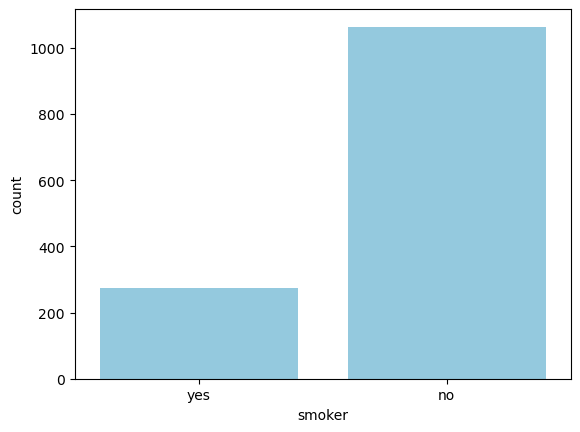

In [397]:
sns.countplot(x=df['smoker'],color = "skyblue")

<Axes: xlabel='sex', ylabel='count'>

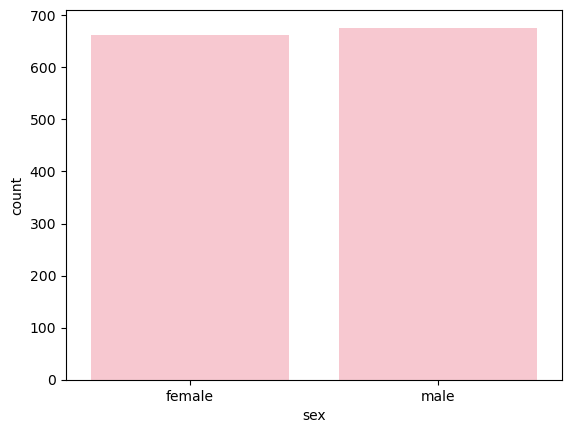

In [398]:
sns.countplot(x=df['sex'], color = "pink")

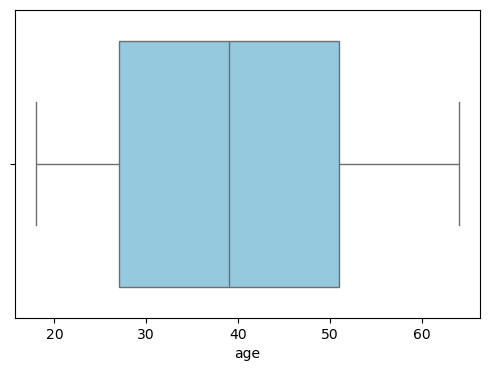

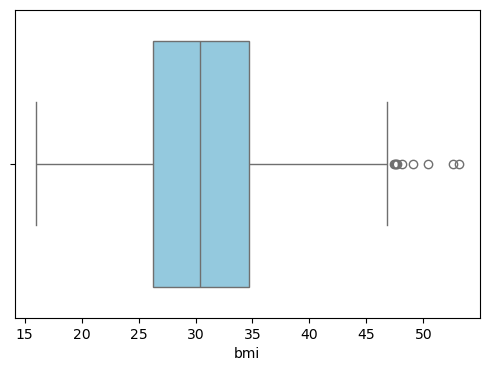

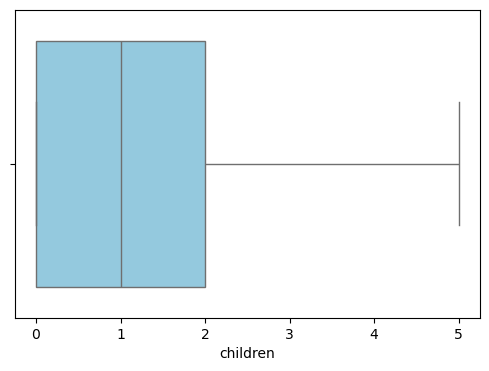

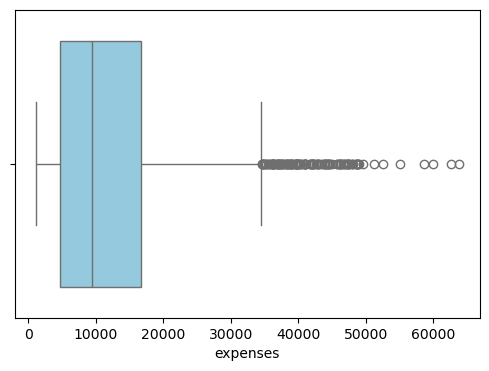

In [399]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[col],color = "skyblue")

<Axes: >

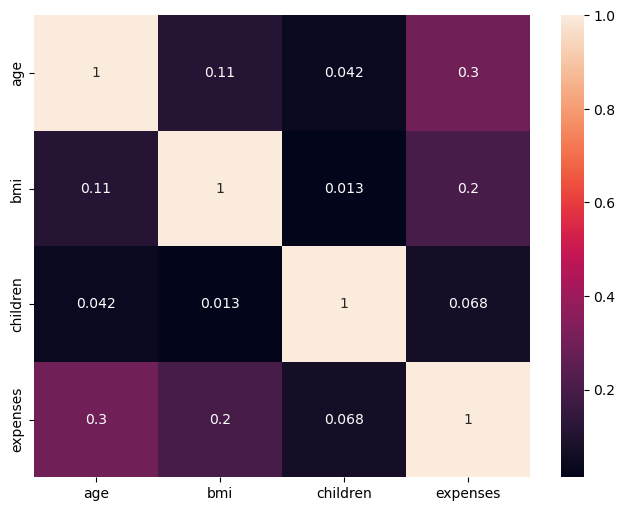

In [400]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot= True)

**DATA CLEANING AND PREPROCESSING**

In [401]:
df_cleaned = df.copy()

In [402]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [403]:
df_cleaned.drop_duplicates(inplace=True)

**data did not have duplicates**

In [404]:
df.shape

(1338, 7)

In [405]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [406]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male":0 , "female":1})

In [407]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,1,27.9,0,yes,southwest,16884.92
1,18,0,33.8,1,no,southeast,1725.55
2,28,0,33.0,3,no,southeast,4449.46
3,33,0,22.7,0,no,northwest,21984.47
4,32,0,28.9,0,no,northwest,3866.86


In [408]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({"yes":1 , "no": 0})

In [409]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,1,27.9,0,1,southwest,16884.92
1,18,0,33.8,1,0,southeast,1725.55
2,28,0,33.0,3,0,southeast,4449.46
3,33,0,22.7,0,0,northwest,21984.47
4,32,0,28.9,0,0,northwest,3866.86


In [410]:
df_cleaned = pd.get_dummies(df_cleaned, columns =['region'], dtype= int )

In [411]:
df_cleaned

,age,sex,bmi,children,smoker,expenses,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.9,0,1,16884.92,0,0,0,1
1,18,0,33.8,1,0,1725.55,0,0,1,0
2,28,0,33.0,3,0,4449.46,0,0,1,0
3,33,0,22.7,0,0,21984.47,0,1,0,0
4,32,0,28.9,0,0,3866.86,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,31.0,3,0,10600.55,0,1,0,0
1334,18,1,31.9,0,0,2205.98,1,0,0,0
1335,18,1,36.9,0,0,1629.83,0,0,1,0
1336,21,1,25.8,0,0,2007.95,0,0,0,1


<Axes: xlabel='bmi', ylabel='Count'>

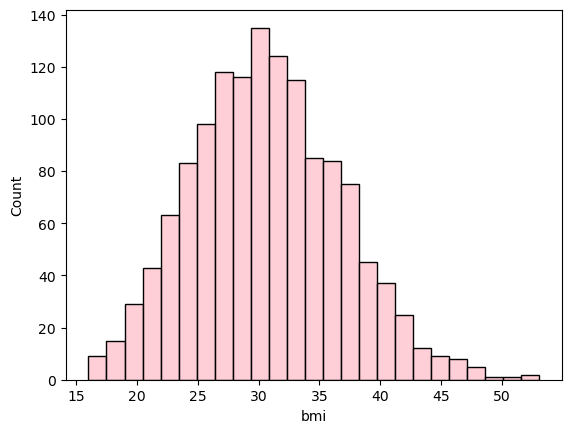

In [412]:
sns.histplot(df_cleaned ['bmi'] , color = 'pink')

In [413]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5,24.5,29.9,float('inf')],
    labels = ['Underweight','Normal', 'Overweight' , 'Obese']

)

In [414]:
df_cleaned

,age,sex,bmi,children,smoker,expenses,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.9,0,1,16884.92,0,0,0,1,Overweight
1,18,0,33.8,1,0,1725.55,0,0,1,0,Obese
2,28,0,33.0,3,0,4449.46,0,0,1,0,Obese
3,33,0,22.7,0,0,21984.47,0,1,0,0,Normal
4,32,0,28.9,0,0,3866.86,0,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,31.0,3,0,10600.55,0,1,0,0,Obese
1334,18,1,31.9,0,0,2205.98,1,0,0,0,Obese
1335,18,1,36.9,0,0,1629.83,0,0,1,0,Obese
1336,21,1,25.8,0,0,2007.95,0,0,0,1,Overweight


In [415]:
df_cleaned = pd.get_dummies(df_cleaned, columns =['bmi_category'], dtype= int,drop_first= True )

In [416]:
df_cleaned

,age,sex,bmi,children,smoker,expenses,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27.9,0,1,16884.92,0,0,0,1,0,1,0
1,18,0,33.8,1,0,1725.55,0,0,1,0,0,0,1
2,28,0,33.0,3,0,4449.46,0,0,1,0,0,0,1
3,33,0,22.7,0,0,21984.47,0,1,0,0,1,0,0
4,32,0,28.9,0,0,3866.86,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,31.0,3,0,10600.55,0,1,0,0,0,0,1
1334,18,1,31.9,0,0,2205.98,1,0,0,0,0,0,1
1335,18,1,36.9,0,0,1629.83,0,0,1,0,0,0,1
1336,21,1,25.8,0,0,2007.95,0,0,0,1,0,1,0


In [417]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])


In [418]:
df_cleaned.head()

,age,sex,bmi,children,smoker,expenses,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.453484,-0.909234,1,16884.92,0,0,0,1,0,1,0
1,-1.511647,0,0.513986,-0.079442,0,1725.55,0,0,1,0,0,0,1
2,-0.799350,0,0.382803,1.580143,0,4449.46,0,0,1,0,0,0,1
3,-0.443201,0,-1.306169,-0.909234,0,21984.47,0,1,0,0,1,0,0
4,-0.514431,0,-0.289506,-0.909234,0,3866.86,0,1,0,0,0,1,0


In [419]:
df_cleaned.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'expenses',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Normal', 'bmi_category_Overweight',
       'bmi_category_Obese'],
      dtype='object')

In [420]:
from scipy.stats import pearsonr

features = ['age', 'children', 'bmi', 'sex', 'smoker',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Normal', 'bmi_category_Overweight',
       'bmi_category_Obese']

for col in features:
    corr, p_value = pearsonr(df_cleaned[col], df_cleaned['expenses'])
    print(f"{col}: correlation = {corr:.3f}, p-value = {p_value:.4f}")

age: correlation = 0.298, p-value = 0.0000
children: correlation = 0.067, p-value = 0.0137
bmi: correlation = 0.199, p-value = 0.0000
sex: correlation = -0.058, p-value = 0.0338
smoker: correlation = 0.787, p-value = 0.0000
region_northeast: correlation = 0.006, p-value = 0.8281
region_northwest: correlation = -0.039, p-value = 0.1573
region_southeast: correlation = 0.074, p-value = 0.0071
region_southwest: correlation = -0.044, p-value = 0.1107
bmi_category_Normal: correlation = -0.113, p-value = 0.0000
bmi_category_Overweight: correlation = -0.116, p-value = 0.0000
bmi_category_Obese: correlation = 0.200, p-value = 0.0000


In [421]:
cat_features = ['sex', 'smoker' , 'region_northeast' , 'region_northwest','region_southeast', 'region_southwest','bmi_category_Normal','bmi_category_Overweight','bmi_category_Obese']


In [422]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['expense_bin'] = pd.qcut(
    df['expenses'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

chi2_result = {}

for col in cat_features:
    table = pd.crosstab(df_cleaned['expense_bin'], df_cleaned [col])

    chi2, p_value, dof, expected = chi2_contingency(table)

    chi2_result[col] = {
        'chi2': chi2,
        'p_value': p_value,
        'dof': dof
    }

    print(f"\n{col}")
    print("Chi-square:", chi2)
    print("p-value:", p_value)
    print("Degrees of freedom:", dof)

    if p_value < alpha:
        print("Significant relationship")
    else:
        print("No significant relationship")


sex
Chi-square: 9.467253404970537
p-value: 0.023682293134021627
Degrees of freedom: 3
Significant relationship

smoker
Chi-square: 853.2888190740186
p-value: 1.198625094485044e-184
Degrees of freedom: 3
Significant relationship

region_northeast
Chi-square: 5.895750830933139
p-value: 0.11679380868053028
Degrees of freedom: 3
No significant relationship

region_northwest
Chi-square: 1.194988317427358
p-value: 0.7542065694906167
Degrees of freedom: 3
No significant relationship

region_southeast
Chi-square: 15.252300237262633
p-value: 0.0016132546708002495
Degrees of freedom: 3
Significant relationship

region_southwest
Chi-square: 5.517987889226108
p-value: 0.13756669221831594
Degrees of freedom: 3
No significant relationship

bmi_category_Normal
Chi-square: 6.598785428078642
p-value: 0.08584701199922283
Degrees of freedom: 3
No significant relationship

bmi_category_Overweight
Chi-square: 3.7363348467171154
p-value: 0.29137880935095023
Degrees of freedom: 3
No significant relationship

In [423]:
final_df = df_cleaned[['sex','smoker','region_southeast','bmi_category_Obese','expenses']]

In [424]:
final_df

,sex,smoker,region_southeast,bmi_category_Obese,expenses
0,1,1,0,0,16884.92
1,0,0,1,1,1725.55
2,0,0,1,1,4449.46
3,0,0,0,0,21984.47
4,0,0,0,0,3866.86
...,...,...,...,...,...
1333,0,0,0,1,10600.55
1334,1,0,0,1,2205.98
1335,1,0,1,1,1629.83
1336,1,0,0,0,2007.95


In [425]:
from sklearn.model_selection import train_test_split

In [426]:
X = final_df.drop('expenses', axis = 1)
Y = final_df['expenses']

In [427]:
X_train, X_test, Y_train, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42
) 

In [428]:
from sklearn.linear_model import LinearRegression

In [429]:
model = LinearRegression()
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [430]:
y_pred = model.predict(X_test)

In [431]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test , y_pred)


n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1-(1-r2)*(n-1) / (n-p-1)

print("R2:" , r2*100)
print("Adjusted R2:", adjusted_r2*100)


R2: 70.61098736919762
Adjusted R2: 70.164006188501
